In [1]:
import numpy as np
import pandas as pd
import os
from PIL import Image
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
os.listdir('/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Train')

['Tumor', 'Without_Tumor']

In [3]:
from matplotlib import image
im=plt.imread('/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Train/Tumor/y1026.jpg')
im.shape

(630, 630, 3)

In [4]:

def Load_imgs(imagepath):
  imgs=[]
  label=[]
  li=os.listdir(imagepath)
  for i in li:
    if i!="Rice_citation_Request.txt":
      l2=os.listdir(imagepath+'/'+i)
      for j in l2:
        c=0
        img=Image.open(imagepath+i+'/'+j)
        img=img.resize(size=(32,32))
        img=img.convert('L')
        imgs.append(np.array(img).flatten())
        label.append(i)
        del img
  return np.array(imgs),label


In [5]:
x,y=Load_imgs("/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Train/")

In [8]:
dimen=x.ndim
dimen

2

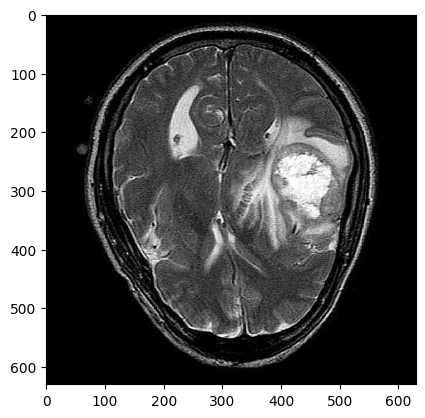

In [ ]:
from PIL import Image
im=Image.open("/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Train/Tumor/y1026.jpg")
plt.imshow(im)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
class CustomDataGenerator(ImageDataGenerator):
  def __init__(self,
               red_range=None,
               green_range=None,
               blue_range=None,
               **kwargs):
    '''
    Custom image data generator.
    Behaves like ImageDataGenerator, but allows color augmentation.
    '''
    super().__init__(
        preprocessing_function=self.augment_color,
        **kwargs)

    self.red_range = red_range
    self.green_range = green_range
    self.blue_range = blue_range

  def augment_color(self, image):
    '''Takes an input image and returns a modified version of it'''
    channel_ranges = (self.red_range, self.green_range, self.blue_range)
    for channel, channel_range in enumerate(channel_ranges):
      if not channel_range:
        continue  # no range set, so don't change that channel
      scale = random.uniform(channel_range[0], channel_range[1])
      image[:, :, channel] = image[:, :, channel] * scale

    image = np.clip(image, 0, 255)
    return image

In [ ]:
datagen = CustomDataGenerator(red_range=(0.8, 1.2),
                              green_range=(0.8, 1.2),
                              blue_range=(0.8, 1.2),
                              brightness_range=(0.5, 1.5),
                              dtype=int)
datagen.fit(im)
plot_augmentation(datagen, im, n_rows=2, n_cols=6)

ValueError: ignored

In [ ]:
data = np.array(x)
data.shape


(3067, 1024)

In [ ]:
x.shape
x_data=x

In [ ]:
x_data.shape

(3067, 1024)

In [ ]:
target=pd.Series(y,dtype="category")
y_data=target.cat.codes


In [ ]:
dicti=dict(enumerate(target.cat.categories))

In [ ]:
print(dicti)

{0: 'Tumor', 1: 'Without_Tumor'}


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_temp,y_train,y_temp=train_test_split(x_data,y_data, test_size=0.2, random_state=42, shuffle=True)
x_val,x_test,y_val,y_test=train_test_split(x_temp,y_temp, test_size=0.5, random_state=42, shuffle=True)

In [ ]:
x_train.shape, x_test.shape

((2453, 1024), (307, 1024))

In [ ]:
y_train.shape, y_test.shape

((2453,), (307,))

In [ ]:
x_val.shape, y_val.shape

((307, 1024), (307,))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model=Sequential()
model.add(Dense(64,input_dim=x_train.shape[1],activation='relu', name='sh_dense1'))
model.add(Dense(120,activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(5,activation='softmax', name='sh_dense2'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy',])



In [ ]:
model.summary()

Model: "sequential_21"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sh_dense1 (Dense)           (None, 64)                65600     
                                                                 
 dense_42 (Dense)            (None, 120)               7800      
                                                                 
 dense_43 (Dense)            (None, 256)               30976     
                                                                 
 sh_dense2 (Dense)           (None, 5)                 1285      
                                                                 
Total params: 105661 (412.74 KB)
Trainable params: 105661 (412.74 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
history=model.fit(x_train,y_train, epochs=30, validation_data=(x_val, y_val))

Epoch 1/30
77/77 [==============================] - 1s 7ms/step - loss: 4.1497 - accuracy: 0.6457 - val_loss: 0.8300 - val_accuracy: 0.7036
Epoch 2/30
77/77 [==============================] - 0s 5ms/step - loss: 0.8862 - accuracy: 0.7550 - val_loss: 1.1523 - val_accuracy: 0.7622
Epoch 3/30
77/77 [==============================] - 0s 5ms/step - loss: 0.5957 - accuracy: 0.7949 - val_loss: 0.9835 - val_accuracy: 0.7687
Epoch 4/30
77/77 [==============================] - 0s 4ms/step - loss: 0.4804 - accuracy: 0.8243 - val_loss: 0.3110 - val_accuracy: 0.8371
Epoch 5/30
77/77 [==============================] - 0s 5ms/step - loss: 0.2845 - accuracy: 0.8850 - val_loss: 0.2177 - val_accuracy: 0.9186
Epoch 6/30
77/77 [==============================] - 0s 5ms/step - loss: 0.3634 - accuracy: 0.8532 - val_loss: 0.4442 - val_accuracy: 0.8469
Epoch 7/30
77/77 [==============================] - 0s 5ms/step - loss: 0.3331 - accuracy: 0.8679 - val_loss: 0.3084 - val_accuracy: 0.8730
Epoch 8/30
77/77 [==

In [ ]:
pred=np.argmax(model.predict(x_test), axis=1)

10/10 [==============================] - 0s 2ms/step


In [ ]:
pred

array([0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
y_test

30      0
2117    1
2717    1
219     0
298     0
       ..
194     0
817     0
601     0
1313    0
2525    1
Length: 307, dtype: int8

In [ ]:
cm=confusion_matrix(y_test, pred)

In [ ]:
cm

array([[157,   5],
       [  5, 140]])

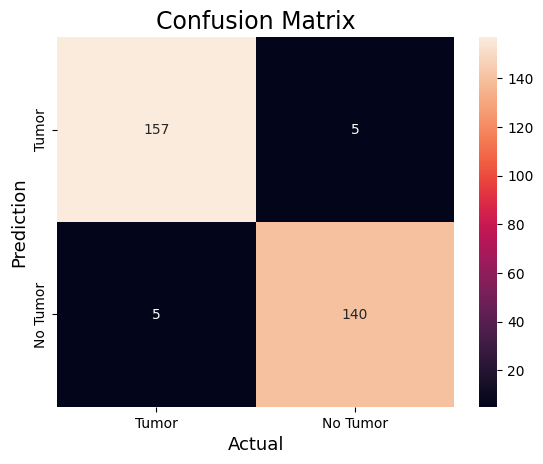

In [ ]:
sns.heatmap(cm,
            annot=True,
            fmt='g',
            xticklabels=['Tumor','No Tumor'],
            yticklabels=['Tumor','No Tumor'])

plt.ylabel('Prediction',fontsize=13)
plt.xlabel('Actual',fontsize=13)
plt.title('Confusion Matrix', fontsize=17)
plt.show()

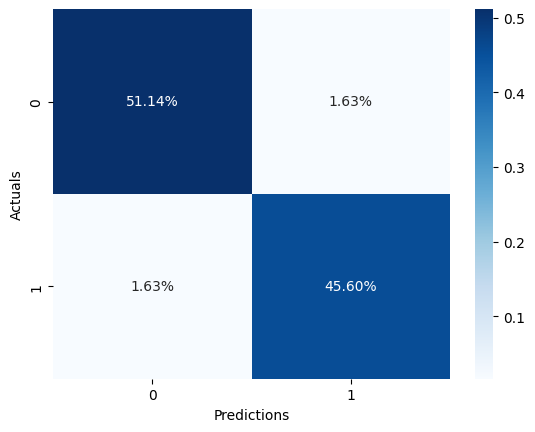

In [ ]:
sns.heatmap(cm/np.sum(cm),annot=True,
            fmt='.2%', cmap='Blues')
plt.ylabel('Actuals')
plt.xlabel('Predictions')
plt.show()

In [ ]:
#Finding precision and Recall
accuracy=accuracy_score(y_test, pred)
print("Accuracy: ", accuracy)
precision=precision_score(y_test, pred)
print("Precision: ", precision)
recall=recall_score(y_test, pred)
print("Recall: ", recall)
F1_score=f1_score(y_test,pred)
print("F1-score: ", F1_score)
auc_score=roc_auc_score(y_test, pred)
print("AUC-score: ", auc_score)
loss=model.evaluate(x_test,y_test)
print('Loss: ',loss)





Accuracy:  0.9674267100977199
Precision:  0.9655172413793104
Recall:  0.9655172413793104
F1-score:  0.9655172413793104
AUC-score:  0.9673265219242232
10/10 [==============================] - 0s 3ms/step - loss: 0.1182 - accuracy: 0.9674
Loss:  [0.11820974946022034, 0.9674267172813416]


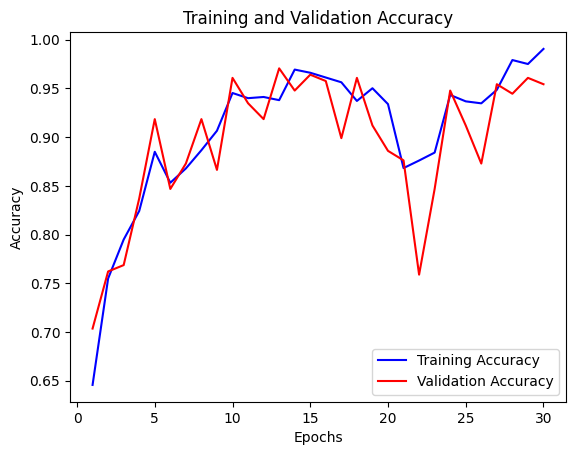

In [ ]:

# Extract training and validation accuracy from history
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Create an array of the epoch numbers
epochs = range(1, len(train_accuracy) + 1)

# Plot the training and validation accuracy curves
plt.plot(epochs, train_accuracy, 'b', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

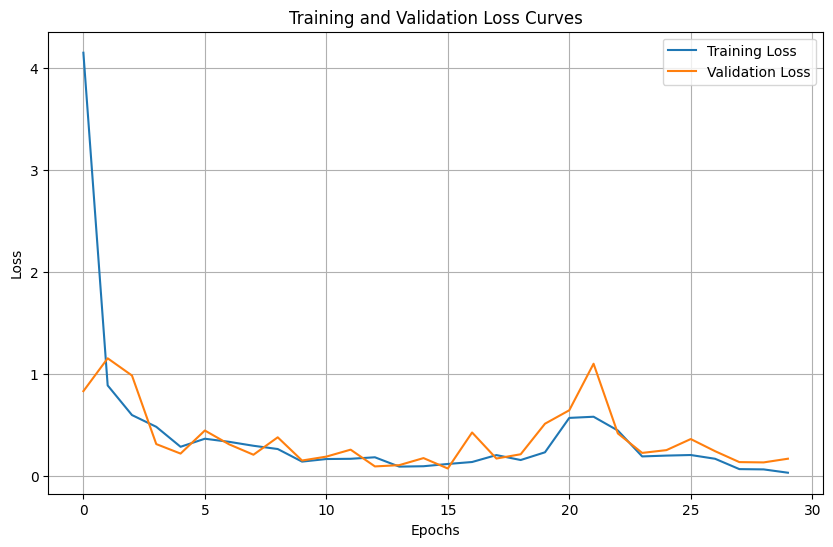

In [ ]:
# Plot the training and validation loss curves
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
accuracy=accuracy_score(y_test, pred)
print(f'Accuracy: {accuracy*100:.2f}%')

Accuracy: 96.74%


In [ ]:
import matplotlib.pyplot as plt

# Example AUC values (replace with your actual AUC scores)
train_auc_values = []
val_auc_values = []




In [ ]:
epochs = 30  # Adjust this based on your needs
for epoch in range(epochs):
    history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=1, verbose=0)

    # Calculate AUC for training and validation data
    y_train_pred =np.argmax(model.predict(x_train),axis=1)
    train_auc= roc_auc_score(y_train, y_train_pred,multi_class='ovo')
    train_auc_values.append(train_auc)

    y_val_pred =np.argmax(model.predict(x_val),axis=1)
    val_auc = roc_auc_score(y_val, y_val_pred,multi_class='ovo')
    val_auc_values.append(val_auc)

    print(f'Epoch {epoch + 1}, Train AUC: {train_auc}, Validation AUC: {val_auc}')


10/10 [==============================] - 0s 3ms/step
Epoch 1, Train AUC: 0.9704464887352414, Validation AUC: 0.9450339558573854
10/10 [==============================] - 0s 2ms/step
Epoch 2, Train AUC: 0.9925511967890311, Validation AUC: 0.980390492359932
10/10 [==============================] - 0s 2ms/step
Epoch 3, Train AUC: 0.9708712975712653, Validation AUC: 0.9256791171477079
10/10 [==============================] - 0s 2ms/step
Epoch 4, Train AUC: 0.993891541909589, Validation AUC: 0.9771646859083192
10/10 [==============================] - 0s 2ms/step
Epoch 5, Train AUC: 0.9939904198283187, Validation AUC: 0.9771646859083192
10/10 [==============================] - 0s 2ms/step
Epoch 6, Train AUC: 0.9929467084639498, Validation AUC: 0.9643251273344652
10/10 [==============================] - 0s 2ms/step
Epoch 7, Train AUC: 0.9231169249699704, Validation AUC: 0.9223896434634974
10/10 [==============================] - 0s 4ms/step
Epoch 8, Train AUC: 0.9875853279817185, Validation AU

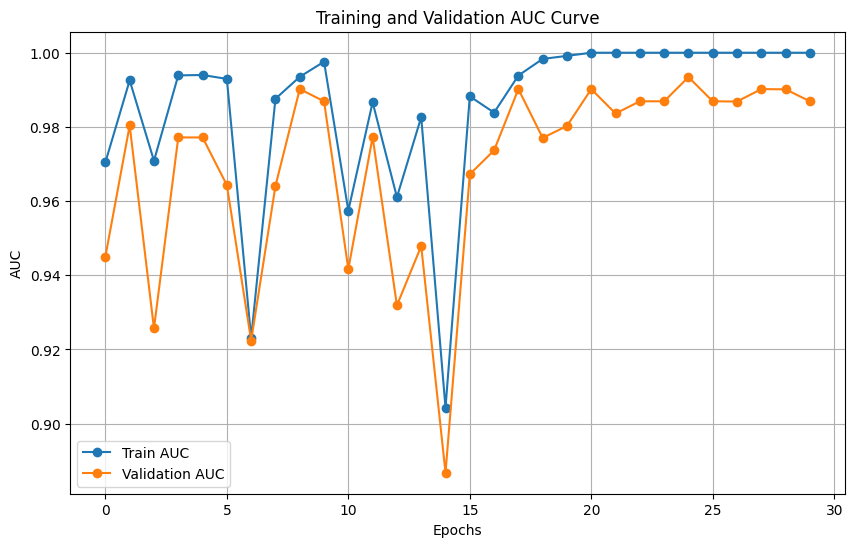

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_auc_values, label='Train AUC', marker='o')
plt.plot(range(epochs), val_auc_values, label='Validation AUC', marker='o')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.title('Training and Validation AUC Curve')
plt.legend()
plt.grid(True)
plt.show()